# 01 — Идентифицируемость $k_s$ на синтетике

Демо PINN-наблюдателя v0: генерируем синтетический рейс (360 дней, 2 очистки
— сокращено для скорости, полные параметры см. `scripts/generate_report.py`),
затем восстанавливаем скрытые состояния двойника:

- $\bar{k}_s(t)$ — средняя шероховатость корпуса [мкм];
- $k_p(t)$ — деградация винта (штраф момента);
- $k_s(x,t)$ — пространственное поле (форма — **априорная**, не идентифицируется
  из интегральных данных, см. docstring `hulltwin.pinn.observer`).

Ключевой факт об идентифицируемости: из судовых логов ship-масштаба данные
содержат ровно одно уравнение на день для корпуса (тождество тяги), поэтому
наблюдаемо только Cf-взвешенное среднее $\bar{k}_s(t)$. Пространственный
градиент требует полосовых данных (IMU/вибрация, локальный тепловой поток).

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch

from hulltwin.data.synthetic import simulate_voyage
from hulltwin.pinn.observer import HullTwinObserver

SEED = 7
N_DAYS = 360
CLEANINGS = (100, 220)
EPOCHS = 1500

torch.manual_seed(SEED)
np.random.seed(SEED)

df = simulate_voyage(n_days=N_DAYS, cleanings=CLEANINGS, seed=SEED)
df.head()

,day,v_meas,hs,wave_heading_deg,rpm_meas,torque_meas,power_meas,fuel_t_day_meas,ks_mean_true,kp_true,days_since_cleaning,cleaning_today
0,0.0,6.705661,4.506626,139.623424,69.495969,220017.584690,1.674017e+06,7622.694244,0.000030,1.00000,0.0,0.0
1,1.0,7.111983,2.446088,54.545837,72.649721,235619.863006,1.861432e+06,8384.594673,0.000031,1.00035,1.0,0.0
2,2.0,7.426524,4.004777,111.992261,76.172473,272319.019503,2.197556e+06,10065.225578,0.000032,1.00070,2.0,0.0
3,3.0,5.544426,2.671466,83.917085,57.991887,157985.334016,9.472088e+05,4296.919611,0.000033,1.00105,3.0,0.0
4,4.0,5.844428,3.521754,36.109210,63.747733,205467.010911,1.359534e+06,6093.974748,0.000034,1.00140,4.0,0.0


## Схема дневного лога

Каждая строка — один день рейса: измеренные скорость/обороты/момент/мощность,
волнение (`hs`, `wave_heading_deg`), флаг очистки и **ground truth** скрытых
состояний (`ks_mean_true`, `kp_true`) — они есть только потому, что это
синтетика; наблюдатель их не видит.

In [2]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
day,360.0,1.795000e+02,104.067286,0.000000,8.975000e+01,1.795000e+02,2.692500e+02,3.590000e+02
v_meas,360.0,6.525161e+00,0.574296,5.453383,6.069140e+00,6.488909e+00,7.032586e+00,7.533707e+00
hs,360.0,2.469899e+00,1.358721,0.213394,1.388182e+00,2.411484e+00,3.552991e+00,4.978373e+00
wave_heading_deg,360.0,9.165598e+01,52.183216,1.672271,4.540306e+01,9.389529e+01,1.356506e+02,1.795965e+02
rpm_meas,360.0,6.841870e+01,5.740717,56.156723,6.371100e+01,6.859598e+01,7.293983e+01,8.191784e+01
torque_meas,360.0,2.375401e+05,43749.625526,146134.361333,2.032329e+05,2.369786e+05,2.650277e+05,3.778232e+05
power_meas,360.0,1.759139e+06,461703.218824,878287.367650,1.393656e+06,1.741119e+06,2.053771e+06,3.181048e+06
fuel_t_day_meas,360.0,7.823897e+03,2036.276486,3826.362552,6.239705e+03,7.779184e+03,9.163903e+03,1.428505e+04
ks_mean_true,360.0,8.455000e-05,0.000033,0.000030,5.677500e-05,8.355000e-05,1.103250e-04,1.551000e-04
kp_true,360.0,1.062825e+00,0.036424,1.000000,1.031413e+00,1.062825e+00,1.094237e+00,1.125650e+00


## Обучение наблюдателя (stage 1)

Loss = $w_{thrust} r_{thrust}^2 + w_{torque} r_{torque}^2 +
w_{dt}(\Delta k_s/k_s)^2$ — все невязки безразмерные. Скачки $k_s$ на днях
очистки исключены из гладкостного штрафа.

In [3]:
observer = HullTwinObserver(n_days=N_DAYS)
history = observer.fit(df, epochs=EPOCHS, lr=5e-2, verbose_every=500)

epoch 500: loss=0.005540
epoch 1000: loss=0.004060
epoch 1500: loss=0.003478


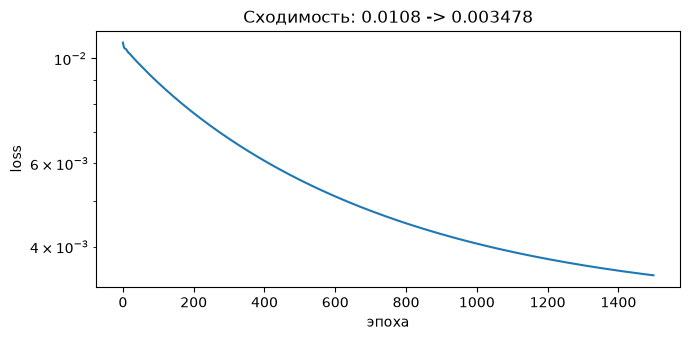

In [4]:
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.semilogy(history)
ax.set_xlabel("эпоха")
ax.set_ylabel("loss")
ax.set_title(f"Сходимость: {history[0]:.4f} -> {history[-1]:.6f}")
fig.tight_layout()

## Восстановление $\bar{k}_s(t)$

corr(k_s) = 0.972


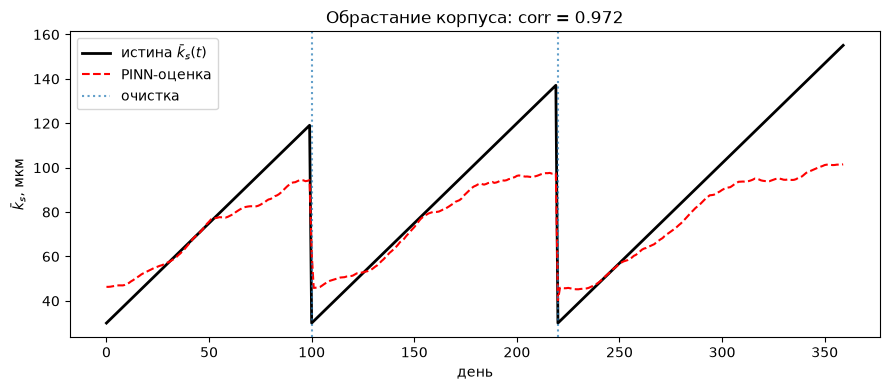

In [5]:
days = np.arange(N_DAYS)
ks_pred = observer.predict_ks_mean(days)
ks_true = df["ks_mean_true"].to_numpy() * 1e6
corr = float(np.corrcoef(ks_pred, ks_true)[0, 1])

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(days, ks_true, "k-", lw=2, label="истина $\\bar{k}_s(t)$")
ax.plot(days, ks_pred, "r--", lw=1.5, label="PINN-оценка")
for i, c in enumerate(CLEANINGS):
    ax.axvline(c, color="tab:blue", ls=":", alpha=0.7, label="очистка" if i == 0 else None)
ax.set_xlabel("день")
ax.set_ylabel("$\\bar{k}_s$, мкм")
ax.set_title(f"Обрастание корпуса: corr = {corr:.3f}")
ax.legend()
fig.tight_layout()
print(f"corr(k_s) = {corr:.3f}")

## Деградация винта $k_p(t)$

Винтовая развязка работает через тождество момента
$Q = \rho n^2 D^5 K_Q(J)\, k_p$: обрастание корпуса не может объяснить
рост момента при неизменном $J$, поэтому $k_p$ отделяется от $k_s$.

ошибка итоговой деградации k_p = 0.76%


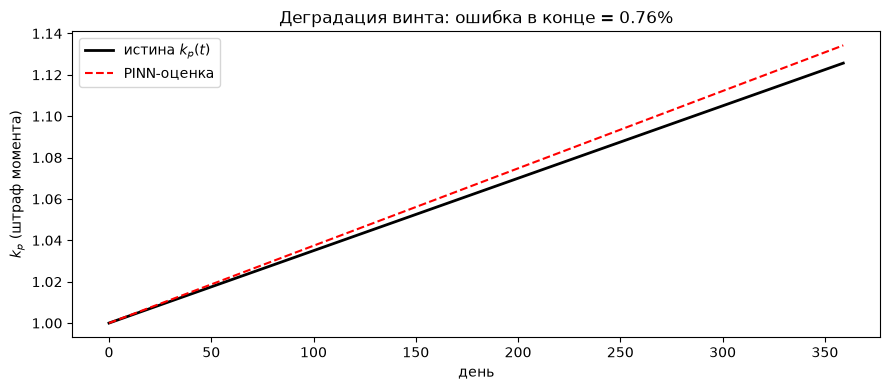

In [6]:
kp_pred = observer.predict_kp(days)
kp_true = df["kp_true"].to_numpy()
err_kp = abs(kp_pred[-1] - kp_true[-1]) / kp_true[-1]

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(days, kp_true, "k-", lw=2, label="истина $k_p(t)$")
ax.plot(days, kp_pred, "r--", lw=1.5, label="PINN-оценка")
ax.set_xlabel("день")
ax.set_ylabel("$k_p$ (штраф момента)")
ax.set_title(f"Деградация винта: ошибка в конце = {err_kp:.2%}")
ax.legend()
fig.tight_layout()
print(f"ошибка итоговой деградации k_p = {err_kp:.2%}")

## Поле $k_s(x, t)$ — диагностика, не измерение

Форма поля восстанавливается как
$k_s(x,t) = \bar{k}_s(t)\,(1 + \beta\,(x/L - 1/2))$ с априорным $\beta$
(корма зарастает быстрее, из ROV-осмотров сестринских судов). Это **не**
идентифицированный профиль: для градиента нужны полосовые данные.

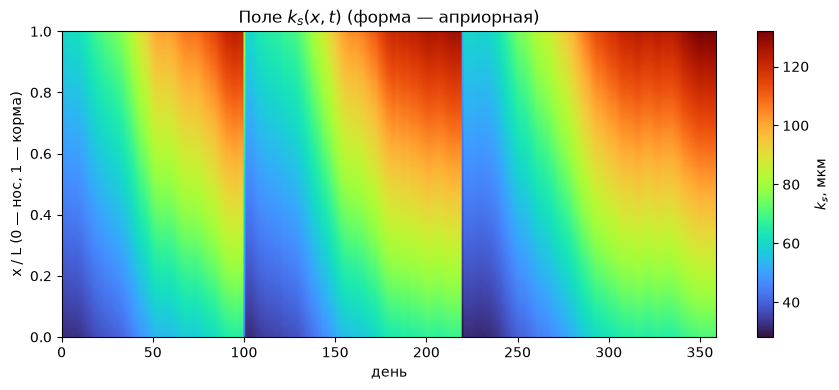

In [7]:
field = observer.predict_ks_field(days, n_x=101)

fig, ax = plt.subplots(figsize=(9, 4))
im = ax.imshow(
    field,
    aspect="auto",
    origin="lower",
    extent=[days[0], days[-1], 0, 1],
    cmap="turbo",
)
fig.colorbar(im, ax=ax, label="$k_s$, мкм")
ax.set_xlabel("день")
ax.set_ylabel("x / L (0 — нос, 1 — корма)")
ax.set_title("Поле $k_s(x,t)$ (форма — априорная)")
fig.tight_layout()

## Выводы

- $\bar{k}_s(t)$ и $k_p(t)$ восстанавливаются устойчиво из дневных логов
  (тождества тяги и момента дают два уравнения на день).
- Пространственный профиль $k_s(x)$ — только диагностика с априорной формой;
  идентификация градиента требует полосовых данных (см. docstring
  `hulltwin.pinn.observer`).
- Следующий шаг по неопределённости — байесовский вывод по $k_s(t)$:
  доверительные интервалы вместо точечных оценок.